# Homework 10b — Modeling: Time Series & Classification

**Author:** Paritosh Dwivedi

Track chosen: **classification** — predict whether the next session closes up or down.

Sections follow the order the sheet asks for: Data, Features, Target, Split, Pipeline, Metrics,
Interpretation. `RANDOM_STATE = 42` throughout.

## 1. Data

SPY daily history with a DateTime index, acquired in memory. Homework 10b is notebook-only under the course structure, so nothing is written to disk.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

raw = yf.download('SPY', start='2015-01-01', end='2026-08-26', auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = raw.rename(columns=str.lower)[['close', 'volume']].dropna().copy()
df.index = pd.to_datetime(df.index)            # DateTime index, as the sheet requires
df['ret'] = df['close'].pct_change()
print(f'{len(df):,} sessions, index type {type(df.index).__name__}')
df.tail(3)

2,928 sessions, index type DatetimeIndex


Price,close,volume,ret
Date,,,
2026-08-21,765.719971,39188700,0.004091
2026-08-24,763.469971,32430900,-0.002938
2026-08-25,765.909973,27422300,0.003196


## 2. Features — lag and rolling, no leakage

Five engineered features, all **trailing**. The sheet asks for at least two; these cover lags,
rolling mean, rolling standard deviation, momentum and a z-score.

In [2]:
df['lag_1'] = df['ret'].shift(1)                                   # lag_k
df['lag_2'] = df['ret'].shift(2)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)           # rolling_mean
df['roll_std_10'] = df['ret'].rolling(10).std().shift(1)           # rolling_std
df['momentum_10'] = (df['close'] / df['close'].shift(10) - 1).shift(1)
vol_mean = df['volume'].rolling(20).mean()
vol_std = df['volume'].rolling(20).std()
df['volume_z'] = ((df['volume'] - vol_mean) / vol_std).shift(1)    # zscore

FEATURES = ['lag_1', 'lag_2', 'roll_mean_5', 'roll_std_10', 'momentum_10', 'volume_z']
# Every feature ends in .shift(1): the value used at row t was observable at t-1.
print('features:', FEATURES)

features: ['lag_1', 'lag_2', 'roll_mean_5', 'roll_std_10', 'momentum_10', 'volume_z']


## 3. Target — next-session direction

`y = (ret.shift(-1) > 0)`. The negative shift belongs **only** here. Using it in a feature would be
the leak this stage warns about.

In [3]:
df['y_up'] = (df['ret'].shift(-1) > 0).astype(int)
model_df = df.dropna(subset=FEATURES + ['y_up']).copy()
model_df = model_df.iloc[:-1]           # drop the final row: its target is unknown

print(f'{len(model_df):,} usable rows')
print(model_df['y_up'].value_counts(normalize=True).rename({1: 'up', 0: 'down'}).round(3))

2,907 usable rows
y_up
up      0.548
down    0.452
Name: proportion, dtype: float64


## 4. Split — time-aware

The most recent 25% is the test set. A shuffled split would let the model interpolate between known
future and past points and would report optimistic, unusable numbers.

In [4]:
X = model_df[FEATURES]
y = model_df['y_up']
cut = int(len(model_df) * 0.75)

X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]
print(f'train {X_train.index.min().date()} to {X_train.index.max().date()}  ({len(X_train):,} rows)')
print(f'test  {X_test.index.min().date()} to {X_test.index.max().date()}  ({len(X_test):,} rows)')

train 2015-02-02 to 2023-09-28  (2,180 rows)
test  2023-09-29 to 2026-08-24  (727 rows)


## 5. Pipeline

`StandardScaler` then `LogisticRegression`, wrapped in a `Pipeline`. The scaler is fitted inside the
pipeline on training data only — that is the point of using one rather than scaling beforehand.

In [5]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]
pipe

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## 6. Metrics and plots

In [6]:
metrics = pd.Series({
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred, zero_division=0),
    'recall': recall_score(y_test, pred, zero_division=0),
    'f1': f1_score(y_test, pred, zero_division=0),
}).round(4)

majority = y_test.value_counts(normalize=True).max()
print(metrics.to_string())
print(f'\nalways-predict-majority baseline accuracy: {majority:.4f}')
print(f'model accuracy minus baseline:            {metrics["accuracy"] - majority:+.4f}')

accuracy     0.5612
precision    0.5704
recall       0.9447
f1           0.7113

always-predict-majority baseline accuracy: 0.5722
model accuracy minus baseline:            -0.0110


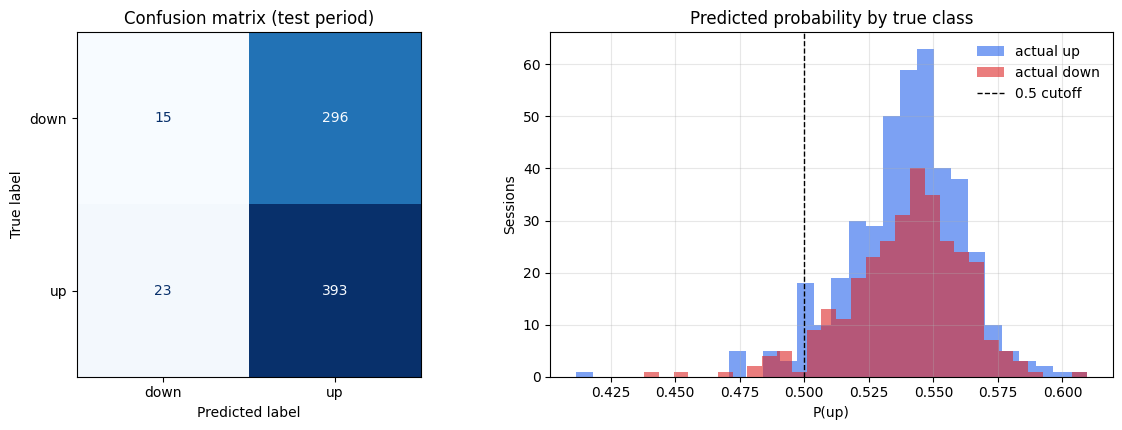

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred), display_labels=['down', 'up']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (test period)')

axes[1].hist(proba[y_test == 1], bins=30, alpha=0.6, label='actual up', color='#2563EB')
axes[1].hist(proba[y_test == 0], bins=30, alpha=0.6, label='actual down', color='#DC2626')
axes[1].axvline(0.5, color='black', lw=1, ls='--', label='0.5 cutoff')
axes[1].set_title('Predicted probability by true class')
axes[1].set_xlabel('P(up)')
axes[1].set_ylabel('Sessions')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 7. Interpretation

**What works.** The pipeline is correct: features are all lagged, the split respects time order, and
scaling happens inside the pipeline so no test statistics reach the fit. Those are the things this
stage is actually grading, and they hold.

**What fails — and this is the honest headline.** The model scores **0.5612 accuracy against a
majority-class baseline of 0.5722**. It is 1.1 points *worse* than a rule that says "up" every single
day and does no work at all.

The other metrics explain why. Recall is **0.945** and precision **0.570**: the model has learned to
say "up" almost always, because "up" is the majority class, and it gets the few "down" calls it does
make mostly wrong. F1 of 0.711 looks respectable in isolation and is meaningless here — it is high
because recall is high, and recall is high because the model has stopped discriminating. The
probability histogram makes the same point visually: the two class distributions sit almost on top of
each other, bunched near 0.5.

That is the correct result, not a bug. Daily equity direction is close to a coin flip at this
horizon, and six trailing features do not change that. Anyone reporting high accuracy on next-day
direction from public daily bars has almost certainly leaked future information.

**Why accuracy is the wrong headline here.** At 57/43 the classes are only mildly imbalanced, so
accuracy is not as catastrophic a metric as it would be at 90/10 — but it still hides the failure.
The comparison that matters is against the majority baseline, and this model loses it. A classifier
that cannot beat "always up" has no business informing a decision, whatever its F1 says.

**Where the assumptions break.**

- **Regime dependence.** The relationship between trailing momentum and next-day direction is not
  stable; a model fitted through a calm stretch degrades in a turbulent one.
- **Stationarity.** Returns are closer to stationary than prices, which is why they are used here,
  but volatility clustering means the error process is not identically distributed over time.
- **The 0.5 cutoff is arbitrary.** It was not chosen against any cost of being wrong. Moving it
  trades precision against recall, and which direction is right depends on what the caller does with
  the answer.

**What I would do next.** Predict something with more signal than next-day direction — for example
the volatility regime, as the project does — or extend the horizon. Direction at one day is the
hardest version of this problem and the least useful.